<a href="https://colab.research.google.com/github/PRANAV-MAGARDE/Odyssey/blob/main/Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded
model done!
testing started
507498496
Accuracy: 0.9296875, Correct: 476, Incorrect: 36
507498496
Accuracy: 0.91796875, Correct: 470, Incorrect: 42
507498496
Accuracy: 0.91015625, Correct: 466, Incorrect: 46
507498496
Accuracy: 0.90625, Correct: 464, Incorrect: 48
507498496
Accuracy: 0.91796875, Correct: 470, Incorrect: 42
507498496
Accuracy: 0.931640625, Correct: 477, Incorrect: 35
507498496
Accuracy: 0.9375, Correct: 480, Incorrect: 32
507498496
Accuracy: 0.9140625, Correct: 468, Incorrect: 44
507498496
Accuracy: 0.921875, Correct: 472, Incorrect: 40
347934720
Accuracy: 0.9068825910931174, Correct: 224, Incorrect: 23
              precision    recall  f1-score   support

  Elliptical       0.90      0.86      0.88      1653
      Spiral       0.93      0.95      0.94      3202

    accuracy                           0.92      4855
   macro avg       0.92      0.90      0.91      4855
weighted avg       0.92      0.92      0.92      4855

Test Loss: 0.21260395646095276, Tes

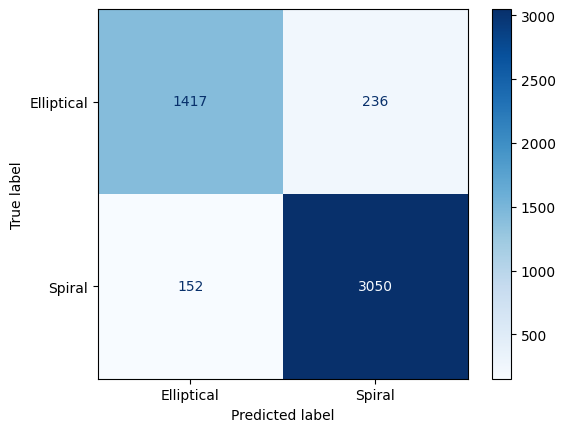

In [ ]:
import torch, os, cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# os.environ['KAGGLE_USERNAME'] = 'erayarising'
# os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f5824c6bfc9fbe40d6dcc318bd6c7ccc'
# %cd /content
# !kaggle competitions download -c galaxy-zoo-the-galaxy-challenge

# !unzip galaxy-zoo-the-galaxy-challenge.zip && unzip images_training_rev1.zip && rm *.zip
# !ls /content/images_training_rev1

def clean_data(input_csv, clean_galaxy_labels, threshold):
    input= pd.read_csv(input_csv)
    input = input[['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3']] #Class 1.1 for elliptical and 1.2 for spiral galaxies; .3 was for uncertain/ stars

    mask = input['Class1.3'] < 0.5
    input = input[mask]
    input['Label'] = -1

    input.loc[input['Class1.2'] >= threshold, 'Label'] = 1
    input.loc[input['Class1.1'] >= threshold, 'Label'] = 0
    clean = input[input['Label'] != -1].copy()
    final = clean[['GalaxyID', 'Label']]
    final.to_csv(clean_galaxy_labels, index=False)
    return clean_galaxy_labels

class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)): #init is a constructor: it runs whenever a new object is created
        self.clip_limit= clip_limit
        self.tile_grid_size= tile_grid_size
        self.clahe= None

    def __call__(self, img):
        if self.clahe is None:
            self.clahe= cv2.createCLAHE(self.clip_limit, self.tile_grid_size)

        img_np = np.array(img)
        lab_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b= cv2.split(lab_img)
        l_new = self.clahe.apply(l)
        lab_merged= cv2.merge((l_new, a, b))
        img_new = cv2.cvtColor(lab_merged, cv2.COLOR_LAB2RGB)

        return Image.fromarray(img_new)

astronomy_transforms = transforms.Compose([
    transforms.CenterCrop(250),
    transforms.Resize((224, 224)),

    ApplyCLAHE(),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class GalaxyZooDataset(Dataset):
    def __init__(self, csv_file, imgs, transforms):
        self.galaxy_frame = pd.read_csv(csv_file)
        self.imgs = imgs
        self.transform = transforms

    def __len__(self):
        return len(self.galaxy_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        galaxy_id = str(self.galaxy_frame.iloc[idx, 0])
        img_name = os.path.join(self.imgs, f"{galaxy_id}.jpg")

        image = Image.open(img_name).convert('RGB')
        label = self.galaxy_frame.iloc[idx, 1]

        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

def test_it(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0,0
    with torch.no_grad():
        for images,labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1)==labels).sum().item()

        acc = correct / len(loader.dataset)
        return total_loss / len(loader), acc


if __name__ == '__main__':
    images_path = '/content/images_training_rev1'

    if not os.path.exists('/content/drive'):
        print("Error: Google Drive is not mounted. Please mount it first (e.g., from the Files menu on the left).")
    else:
        image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if not image_files:
            print(f"Error: No image files found in the directory: {images_path}")
        else:

            galaxy_dataset = GalaxyZooDataset(csv_file=clean_data(input_csv= '/content/drive/MyDrive/training_solutions_rev1.csv',clean_galaxy_labels= 'clean_galaxy_labels.csv', threshold=0.8), imgs= images_path, transforms= astronomy_transforms)
            print("Data Loaded")

            train_size= int(0.8 * len(galaxy_dataset))
            test_size= len(galaxy_dataset) - train_size
            train_data, test_data = random_split(galaxy_dataset, [train_size, test_size])
            train_loader = DataLoader(train_data, batch_size=512, shuffle=True, num_workers=2, pin_memory=True)
            test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model = models.resnet50(weights=None)
            model.fc = nn.Linear(model.fc.in_features, 2)
            model_path = '/content/drive/MyDrive/resnet50_galaxy.pth'
            model.load_state_dict(torch.load(model_path, map_location=device))
            for param in model.parameters():
                param.requires_grad = False
            model = model.to(device)
            print("model done!")

            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

            print("testing started")
            test_loss, test_acc = test_it(model, test_loader, criterion, device)

            all_preds, all_labels=[], []
            with torch.no_grad():
              model.eval()
              for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                # print(torch.cuda.memory_allocated(device))
                pred = output.argmax(1).cpu().numpy()
                target = labels.cpu().numpy()
                all_preds.extend(pred)
                all_labels.extend(target)
                a,b=0,0
                for p,t in zip(pred, target):
                  if p==t:
                    a+=1
                  else:
                    b+=1
                print(f"Accuracy: {a/(a+b)}, Correct: {a}, Incorrect: {b}")

            # model.eval()
            # for images, labels in test_loader:
            #   images, labels = images.to(device), labels.to(device)
            #   output = model(images)
            #   print(torch.cuda.memory_allocated(device)) # Corrected typo from mermory_allocated to memory_allocated
            #   pred = output.argmax(1).cpu().numpy()
            #   target = labels.cpu().numpy()
            #   a,b=0,0
            #   for p,t in zip(pred, target):
            #     if p==t:
            #       a+=1
            #     else:
            #       b+=1
            #   print(f"Accuracy: {a/(a+b)}, Correct: {a}, Incorrect: {b}")

            class_names = ['Elliptical', 'Spiral']
            all_preds, all_labels= np.array(all_preds), np.array(all_labels)
            cm = confusion_matrix(all_labels, all_preds)
            disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=class_names)
            disp.plot(cmap='Blues')
            plt.show
            print(classification_report(all_labels, all_preds, target_names=class_names))
            print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")